# Netflix Content Strategy Analysis

## Objective

### The objective of this project is to analyze Netflix's content catalog and uncover trends related to content growth, genre distribution, country contributions, content ratings, and content characteristics. Through exploratory data analysis (EDA), the project aims to generate actionable insights regarding Netflix's content strategy and global expansion.

## Tools and Technologies Used

### Python Pandas NumPy Matplotlib Seaborn 

### Importing necessary libraries and the datasets.

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

## Dataset Description

### The dataset contains information about Netflix Movies and TV Shows, including details such as title, director, cast, country, release year, content rating, duration, genre, and date added to Netflix.

In [44]:
netflix_titles_df = pd.read_csv("/Users/tanishkagarwal/Downloads/netflix_titles.csv")

## Dataset Understanding

### Previewing the head of dataframe so we know what data we are working with.

In [45]:
netflix_titles_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Observation

### The dataset contains information about Netflix content, including Movies and TV Shows. Features include content type, title, director, cast, country, release year, rating, duration, genre classification, and description. These attributes provide a strong foundation for content trend and business analysis.

## Data Cleaning

In [46]:
netflix_titles_df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [147]:
netflix_titles_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [68]:
netflix_titles_df['director'] = netflix_titles_df['director'].fillna('Unknown')
netflix_titles_df['cast'] = netflix_titles_df['cast'].fillna('Unknown')
netflix_titles_df['country'] = netflix_titles_df['country'].fillna('Unknown')

In [67]:
netflix_titles_df.dropna(subset=['date_added'], inplace=True)

In [63]:
netflix_titles_df['rating'] = netflix_titles_df['rating'].fillna(netflix_titles_df['rating'].mode()[0])

In [64]:
netflix_titles_df.dropna(subset=['duration'], inplace=True)

In [69]:
netflix_titles_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [72]:
netflix_titles_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8794 non-null   object
 1   type          8794 non-null   object
 2   title         8794 non-null   object
 3   director      8794 non-null   object
 4   cast          8794 non-null   object
 5   country       8794 non-null   object
 6   date_added    8794 non-null   object
 7   release_year  8794 non-null   int64 
 8   rating        8794 non-null   object
 9   duration      8794 non-null   object
 10  listed_in     8794 non-null   object
 11  description   8794 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.1+ KB


## Feature Engineering

### let's make some new columns like year_added, month_added, content_age, decade etc. and all to make data more useful.

In [75]:
netflix_titles_df['date_added'] = pd.to_datetime(
    netflix_titles_df['date_added'].str.strip(),  
    format='mixed',  
    errors='coerce' 
)

In [76]:
netflix_titles_df['year_added'] = netflix_titles_df['date_added'].dt.year

In [77]:
netflix_titles_df['month_added'] = netflix_titles_df['date_added'].dt.month_name()

In [78]:
netflix_titles_df['content_age'] =( 2026 - netflix_titles_df['release_year'] )

In [79]:
netflix_titles_df['decade'] = (
    netflix_titles_df['release_year']//10
)*10

In [80]:
netflix_titles_df[
[
'release_year',
'year_added',
'month_added',
'content_age',
'decade'
]
].head()

,release_year,year_added,month_added,content_age,decade
0,2020,2021,September,6,2020
1,2021,2021,September,5,2020
2,2021,2021,September,5,2020
3,2021,2021,September,5,2020
4,2021,2021,September,5,2020


## Question 1: What are the Distribution of Ratings of Netflix Content?

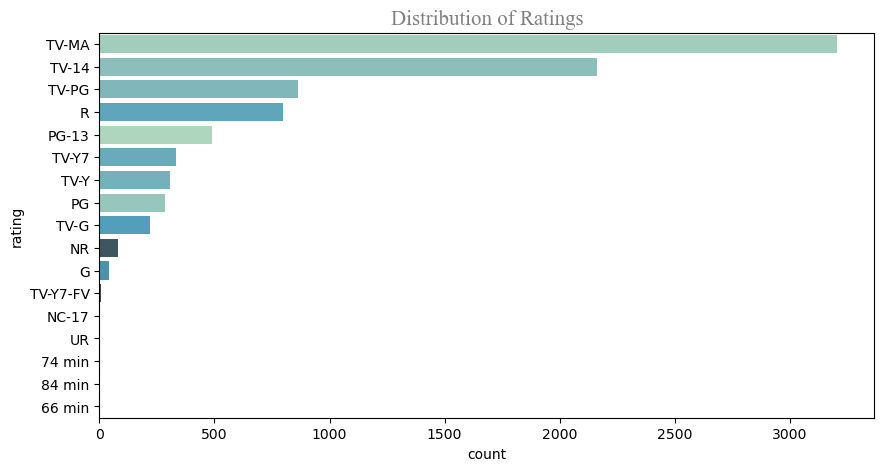

In [59]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='rating',
    data=netflix_titles_df,
    order=netflix_titles_df['rating'].value_counts().index,
    palette = 'GnBu_d',
    hue = 'rating',
    legend=False
)

plt.title('Distribution of Ratings',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Question 2: Which year had the highest content addition?

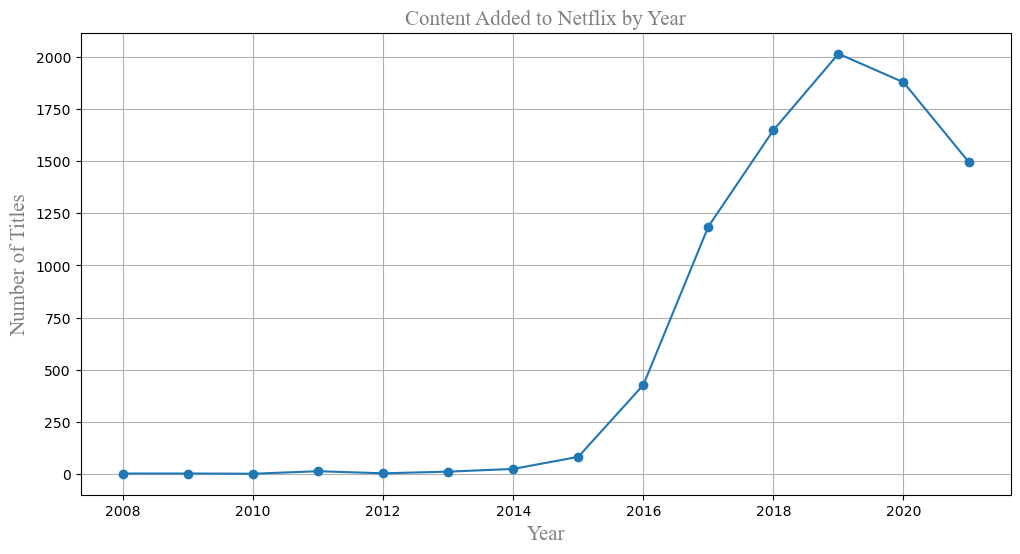

In [85]:
yearly_content = netflix_titles_df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
yearly_content.plot(kind='line', marker='o')

plt.title('Content Added to Netflix by Year',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.xlabel('Year',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Number of Titles',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.grid(True)

plt.show()

## Question 3: What is the trend between Movies and TV Shows Over Years?

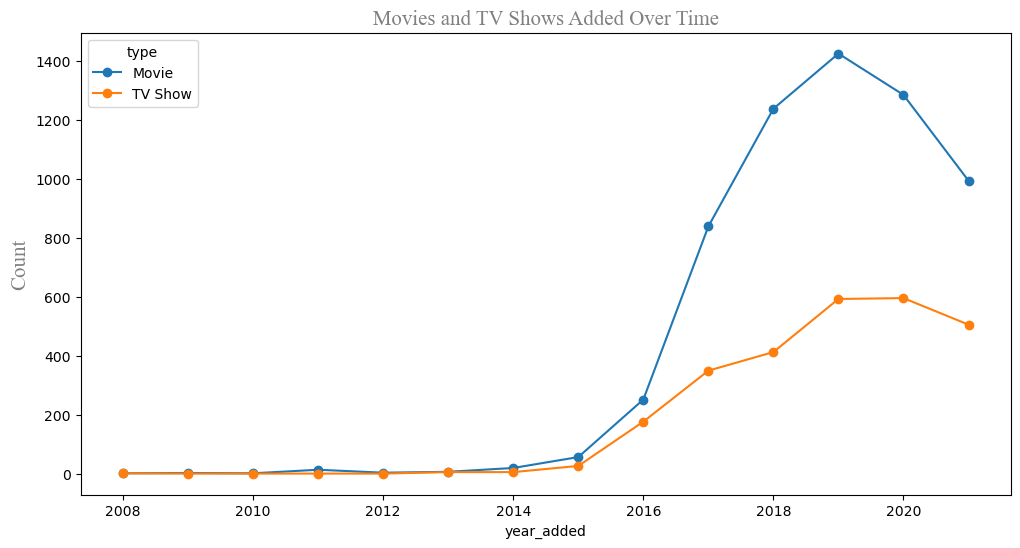

In [86]:
content_by_year = pd.crosstab(
    netflix_titles_df['year_added'],
    netflix_titles_df['type']
)

content_by_year.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Movies and TV Shows Added Over Time',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Count',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.show()

## Question 4: Which are top 15 Countries by Netflix Content?

In [62]:
netflix_titles_df['country'].value_counts().head(15)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Turkey             105
Nigeria             95
Australia           87
Taiwan              81
Indonesia           79
Name: count, dtype: int64

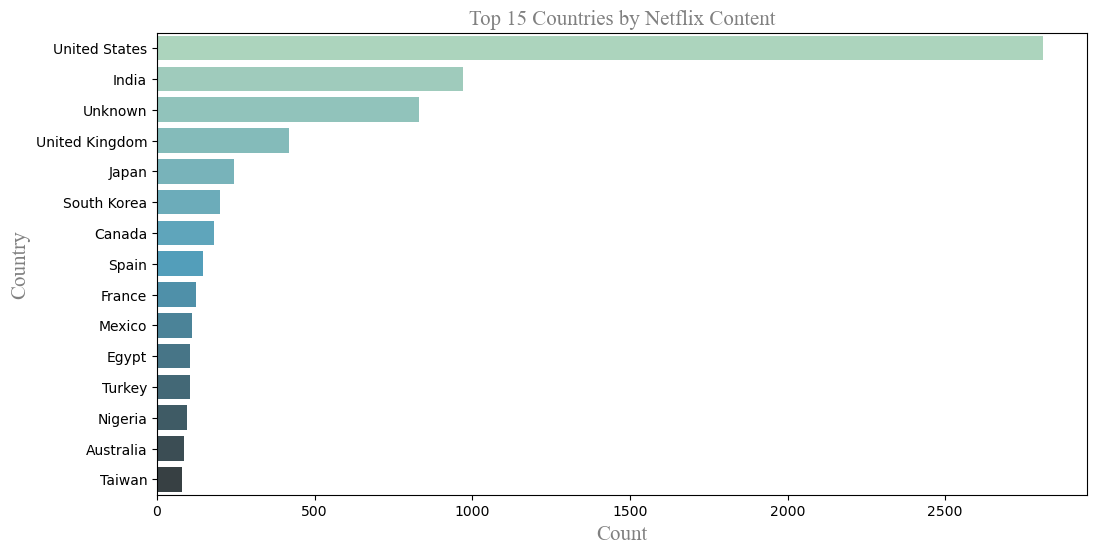

In [81]:
top_countries = netflix_titles_df['country'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette = 'GnBu_d',
    hue = top_countries.index,
    legend=False
)

plt.title('Top 15 Countries by Netflix Content',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.xlabel('Count',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Country',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

In [82]:
netflix_titles_df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

## Question 5: Which are the top 15 Netflix Genres?

### Create a Genre Dataframe.

In [51]:
genre_df = netflix_titles_df.copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')

### Explode Genres.

In [52]:
genre_df = genre_df.explode('listed_in')

In [53]:
top_genres = genre_df['listed_in'].value_counts().head(15)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


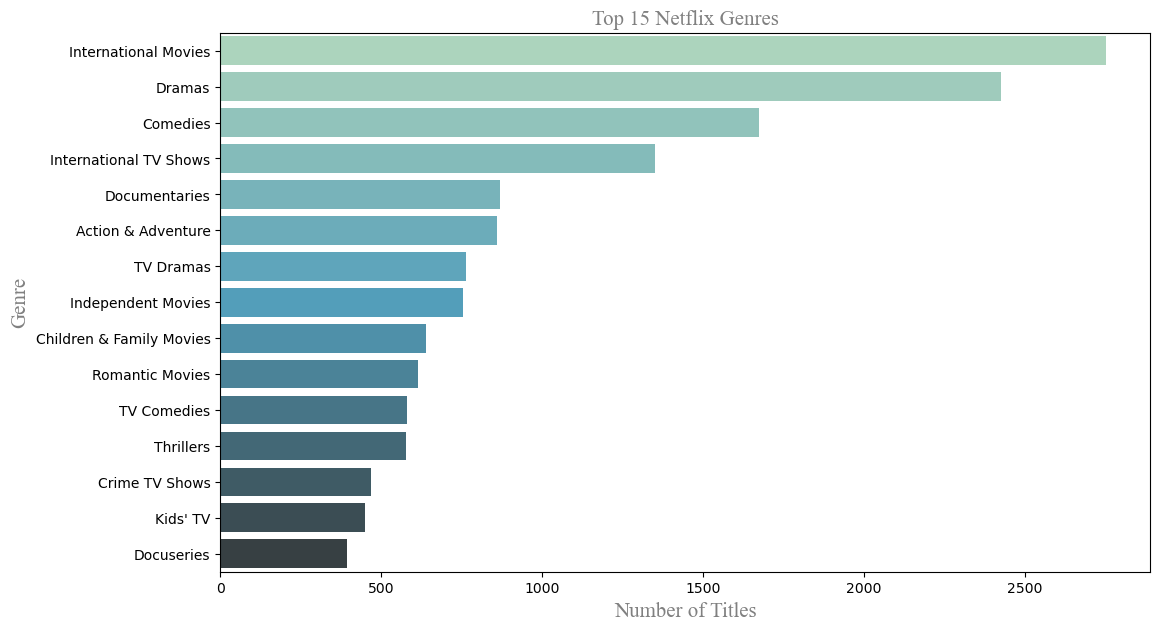

In [54]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette = 'GnBu_d',
    hue = top_genres.index,
    legend=False
)

plt.title('Top 15 Netflix Genres',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.xlabel('Number of Titles',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Genre',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Question 6: Which are the top 15 Content Producing countries?

In [55]:
country_df = netflix_titles_df.copy()
country_df['country'] = country_df['country'].str.split(', ')

In [56]:
country_df = country_df.explode('country')

In [57]:
top_country = country_df['country'].value_counts().head(15)
print(top_country)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64


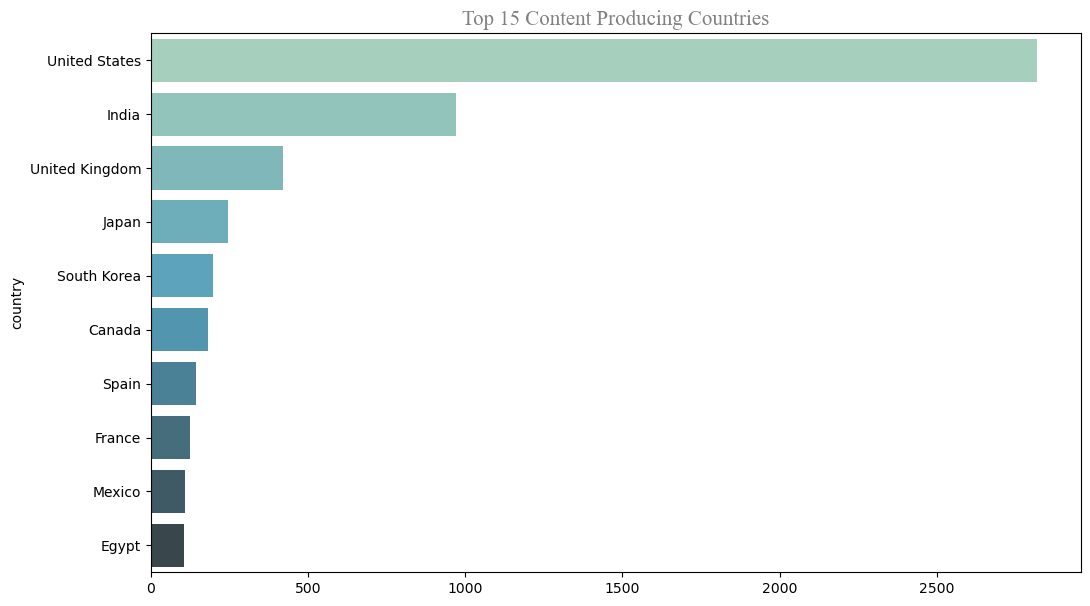

In [58]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette ='GnBu_d',
    hue = top_countries.index,
    legend = False
)

plt.title('Top 15 Content Producing Countries',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Question 7: Which are top 15 Directors?

### Let's first remove the director values with 'Unknown' and calculate top directore among remaining one.

In [79]:
director_df = netflix_titles_df[
    netflix_titles_df['director'] != 'Unknown'
]

In [80]:
top_director = director_df['director'].value_counts().head(10)
print(top_director)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Martin Scorsese           12
Youssef Chahine           12
Steven Spielberg          11
Name: count, dtype: int64


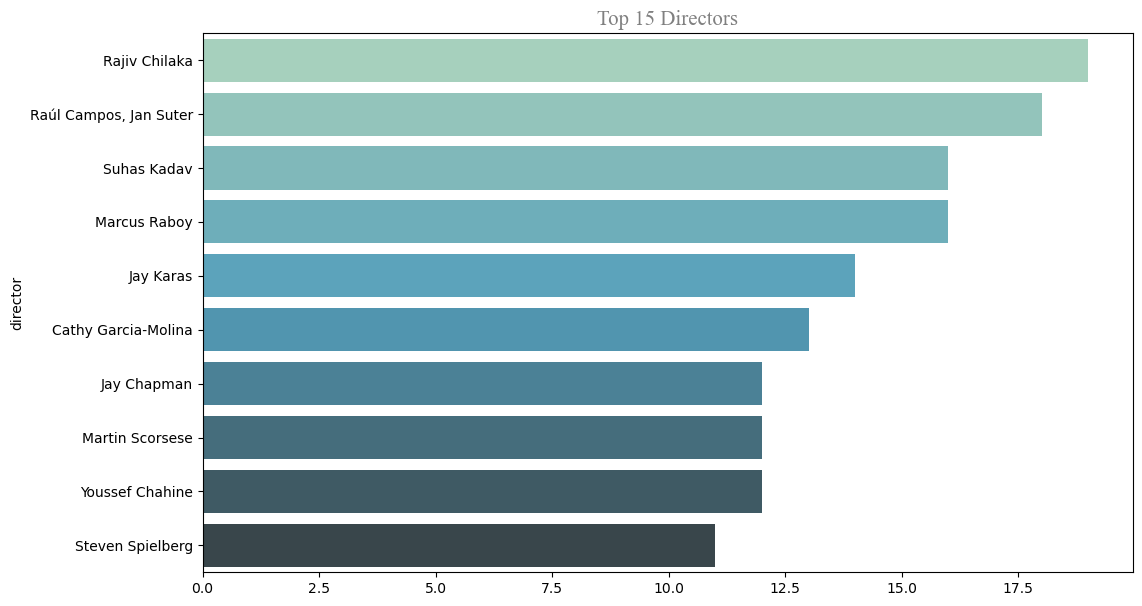

In [84]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_director.values,
    y=top_director.index,
    palette = 'GnBu_d',
    hue=top_director.index,
    legend=False
)

plt.title('Top 15 Directors',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Advanced Netflix Analysis

## Monthly Content Addition Trend

### Let's calculate in which month netlflix add most content.

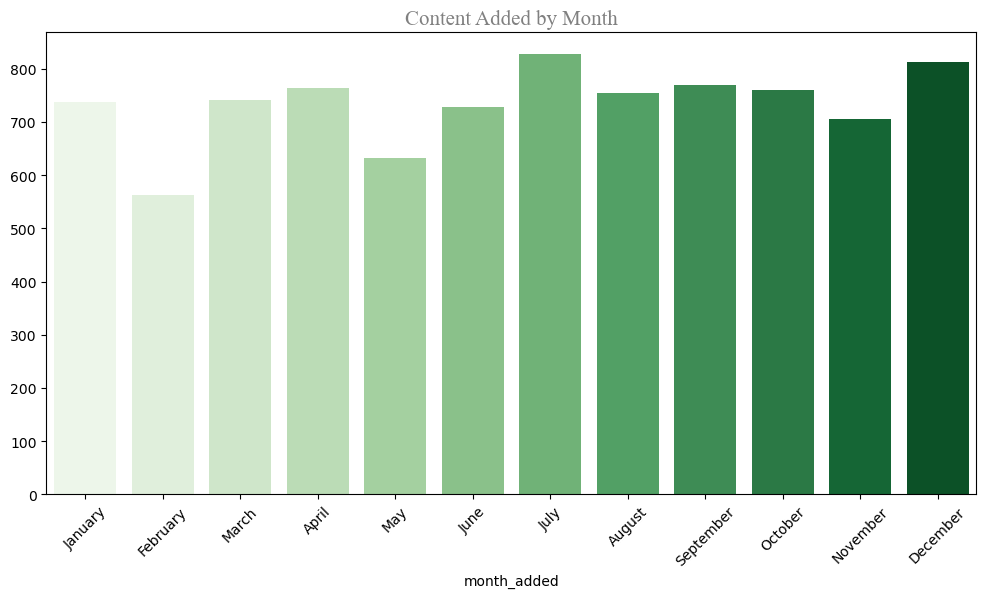

In [86]:
month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

monthly_content = netflix_titles_df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_content.index,
            y=monthly_content.values,
            palette = 'Greens',
            hue=monthly_content.index,
            legend=False)

plt.xticks(rotation=45)
plt.title("Content Added by Month",fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.show()

## Content Age Analysis

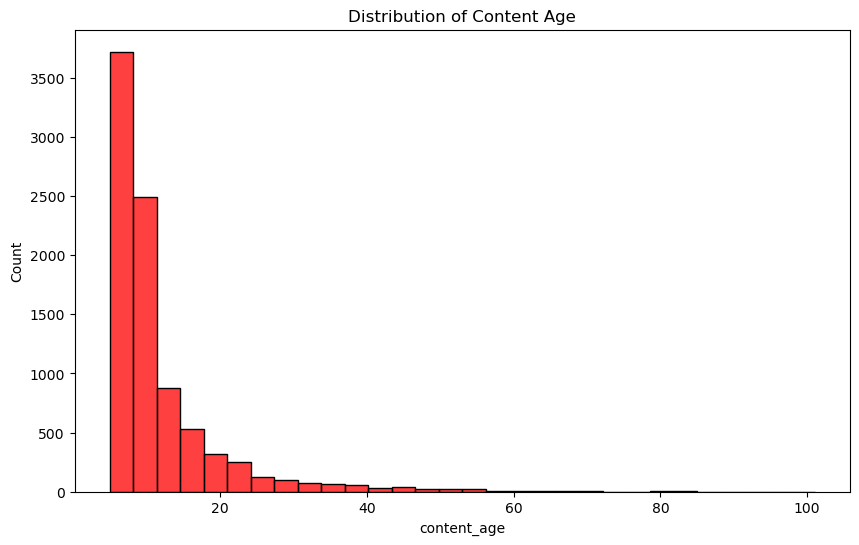

In [107]:
plt.figure(figsize=(10,6))
sns.histplot(netflix_titles_df['content_age'],
             bins=30,
             color = 'red',
             )

plt.title("Distribution of Content Age")
plt.show()

## Movie Duration Analysis

### Separate numeric duration.

In [94]:
movies = netflix_titles_df[
    netflix_titles_df['type']=='Movie'
].copy()

movies['movie_minutes'] = (
    movies['duration']
    .str.replace(' min','')
    .astype(int)
)

### Longest Movies

In [95]:
movies.sort_values(
    by='movie_minutes',
    ascending=False
)[['title','movie_minutes']].head(10)

,title,movie_minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233
2488,Raya and Sakina,230
166,Once Upon a Time in America,229
7932,Sangam,228
1019,Lagaan,224
4573,Jodhaa Akbar,214


### Duration Analysis

sns.histplot(
    movies['movie_minutes'],
    bins=30,
    color='red'
)

plt.show()

## TV Show season Analysis

In [98]:
tv_shows = netflix_titles_df[
    netflix_titles_df['type'] == 'TV Show'
].copy()

tv_shows['seasons'] = (
    tv_shows['duration']
    .str.replace(' Season','', regex=False)  
    .str.replace(' Seasons','', regex=False)  
    .str.replace('s','', regex=False)  
    .str.strip() 
    .str.extract('(\d+)', expand=False)  
    .astype(int) 
)

### Top Shows by Seasons

In [99]:
tv_shows.sort_values(
    by='seasons',
    ascending=False
)[['title','seasons']].head(10)

,title,seasons
548,Grey's Anatomy,17
2423,Supernatural,15
4798,NCIS,15
4220,COMEDIANS of the world,13
1354,Heartland,13
4964,Trailer Park Boys,12
5412,Criminal Minds,12
6456,Cheers,11
390,The Walking Dead,10
1622,Stargate SG-1,10


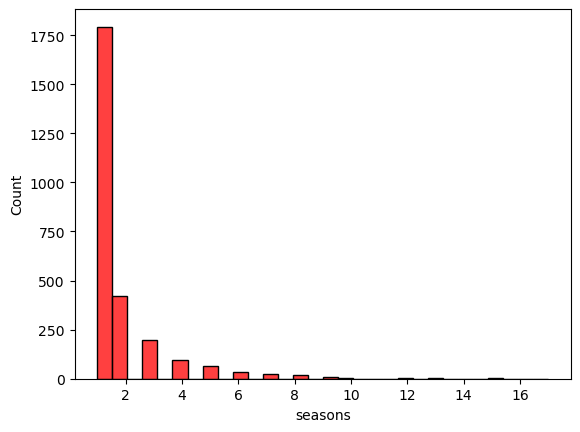

In [109]:
sns.histplot(
    tv_shows['seasons'],
    bins=30,
    color='red'
)
plt.show()

## Genre Trend Analysis

In [110]:
genre_year = pd.crosstab(
    genre_df['year_added'],
    genre_df['listed_in']
)

genre_year.head()

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
year_added,,,,,,,,,,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2010,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2011,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2012,0,0,0,0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


In [117]:
top_genres = genre_df['listed_in'].value_counts().head(5).index
print(top_genres)

Index(['International Movies', 'Dramas', 'Comedies', 'International TV Shows',
       'Documentaries'],
      dtype='object', name='listed_in')


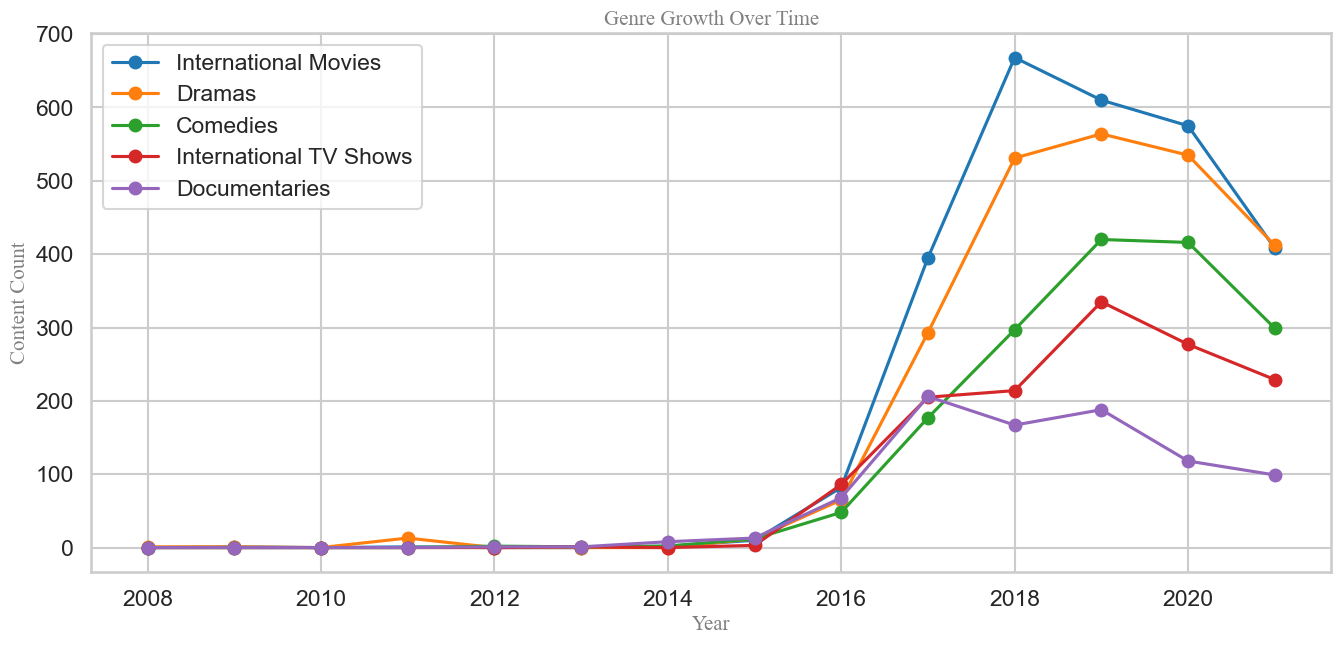

In [123]:
plt.figure(figsize=(16,7))

for genre in top_genres:
    plt.plot(
        genre_year.index,
        genre_year[genre],
        marker='o',
        label=genre,
        
    )

plt.legend()
plt.title('Genre Growth Over Time',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.xlabel('Year',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})
plt.ylabel('Content Count',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Country Growth Trend

In [124]:
country_year = pd.crosstab(
    country_df['year_added'],
    country_df['country']
)

In [127]:
top_countries = (
    country_df['country'].value_counts().head(5).index
)

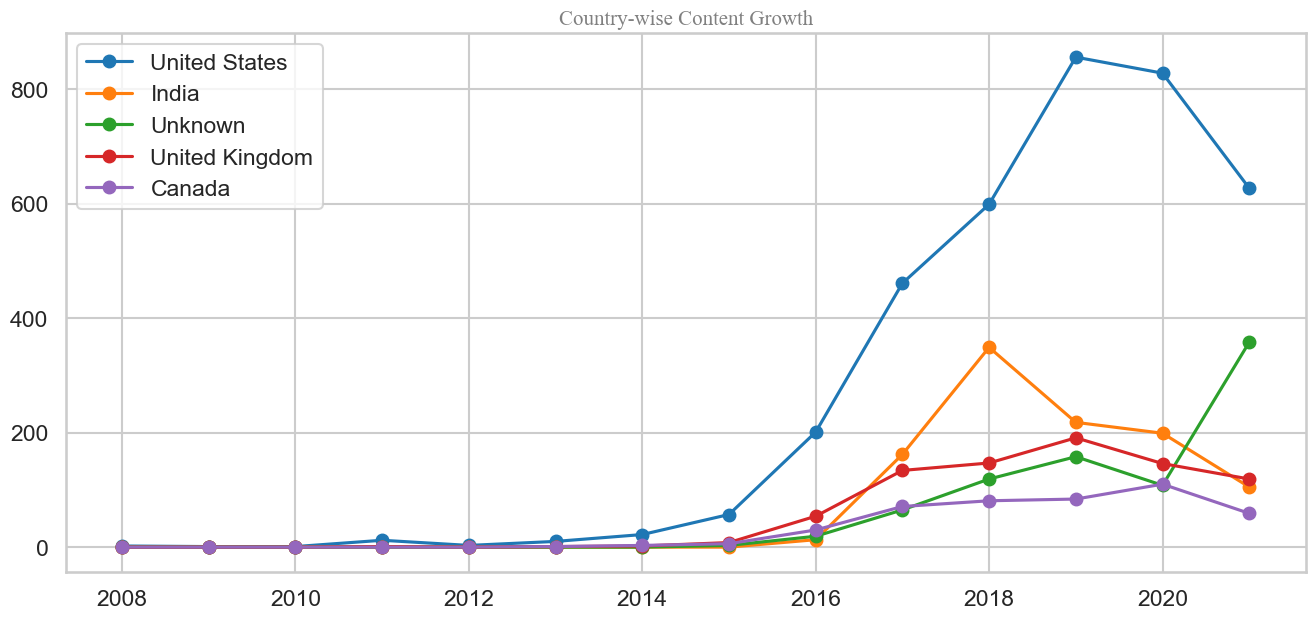

In [130]:
plt.figure(figsize=(16,7))

for country in top_countries:
    plt.plot(
        country_year.index,
        country_year[country],
        marker='o',
        label=country
    )

plt.legend()
plt.title('Country-wise Content Growth',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Correlation Style Analysis

In [132]:
netflix_titles_df['genre_count'] = (
    netflix_titles_df['listed_in']
    .str.count(',')
    +1
)

In [133]:
netflix_titles_df['country_count'] = (
    netflix_titles_df['listed_in']
    .str.count(',')
    +1
)

In [134]:
netflix_titles_df['cast_count'] = (
    netflix_titles_df['listed_in']
    .str.count(',')
    +1
)

In [137]:
netflix_titles_df.groupby('type')[
[
'genre_count',
'country_count',
'cast_count'
]
].mean()

,genre_count,country_count,cast_count
type,,,
Movie,2.151926,2.151926,2.151926
TV Show,2.292948,2.292948,2.292948


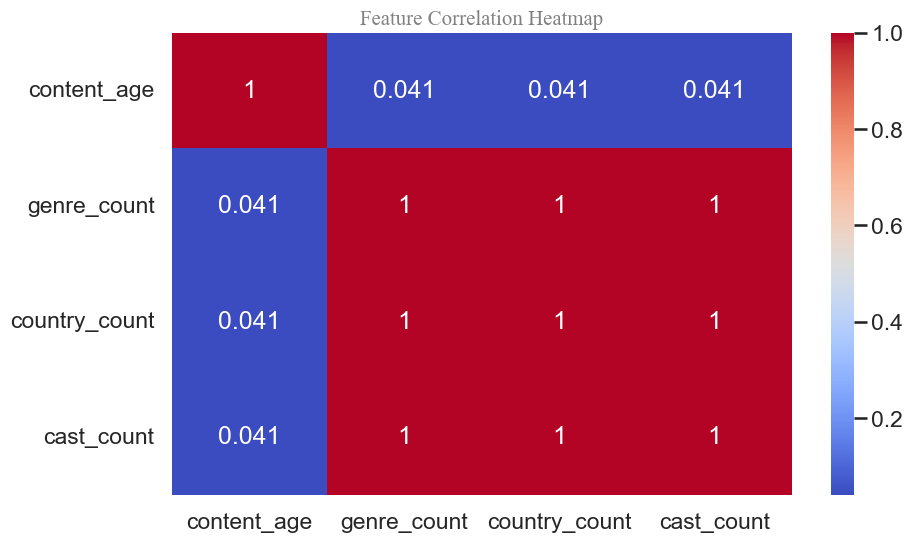

In [142]:
corr_cols = [
'content_age',
'genre_count',
'country_count',
'cast_count'
]

corr = netflix_titles_df[corr_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap',fontdict = {'fontname': 'Times New Roman', 'color': 'gray', 'fontsize' : '15'})

plt.show()

## Key Findings

### - Movies account for nearly 70% of Netflix content.
### - Netflix experienced rapid content growth after 2015.
### - The United States is the largest content contributor.
### - Drama and International Movies dominate the platform.
### - Most Netflix content is relatively recent.

## Recommendations

### - Continue investing in high-performing genres.
### - Expand content partnerships in emerging markets.
### - Maintain a balanced mix of Movies and TV Shows.

## Conclusion

### This project analyzed Netflix's content catalog using Python and data visualization techniques. Through data cleaning, feature engineering, genre analysis, country analysis, and trend analysis, valuable insights were generated regarding Netflix's content strategy and platform growth.